In [16]:
!pip install keras-tuner -q

In [17]:
import numpy as np
import tensorflow as tf
import keras_tuner as kt
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

np.random.seed(0)
tf.random.set_seed(0)

In [18]:
# ==========================================================
# 1. CARGAR DATOS FÍSICOS DESDE EL .DAT
# ==========================================================
# Vamos a extraer 'r', el nivel de energía 'N', y la amplitud 'psi'
r_data, n_data, psi_data = [], [], []
estado_actual = 1

# Cambia el nombre al archivo que estés usando (LITIO.DAT, LITIO_PYTHON.DAT, etc.)
with open("/home/isabel/MFC/PARCIAL/PINN/LITIO_PYTHON0.DAT", "r") as f:
    for linea in f:
        linea = linea.strip()
        if not linea:
            # Los bloques separados por espacios en blanco indican un cambio de estado
            if len(r_data) > 0 and n_data[-1] == estado_actual:
                estado_actual += 1
            continue

        partes = linea.split()
        if len(partes) == 2:
            r_data.append(float(partes[0]))
            n_data.append(estado_actual)
            psi_data.append(float(partes[1]))

X = np.column_stack((r_data, n_data)) # Features: [Posición r, Nivel N]
y = np.array(psi_data)                # Target: [Amplitud de onda psi]

print(f"Total de datos cargados: {len(X)} puntos abarcando {estado_actual - 1} estados.")


Total de datos cargados: 2400 puntos abarcando 4 estados.


In [19]:
# ==========================================================
# 2. TRAIN / VALIDATION / TEST
# ==========================================================
# Usamos un random_state para que los splits sean reproducibles
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42)

In [20]:
# ==========================================================
# 3. NORMALIZACIÓN
# ==========================================================
# Escalar 'r' y 'N' es vital para que la red converja rápido
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [21]:
# ==========================================================
# 4. MODELO CON HIPERPARÁMETROS
# ==========================================================
def build_model(hp):
    model = tf.keras.Sequential()

    # Número de capas ocultas
    for i in range(hp.Int("num_layers", 2, 10)):
        model.add(
            layers.Dense(
                units = hp.Int(f"units_{i}", 32, 256, step=32),
                # tanh suele ser mejor para ondas cuánticas
                activation = hp.Choice("activation", ["relu", "tanh", "swish"]),
                kernel_regularizer=tf.keras.regularizers.l2(
                    hp.Float("l2", 1e-6, 1e-3, sampling="log")
                )
            )
        )

        # Dropout suave para evitar overfitting
        model.add(layers.Dropout(hp.Float(f"dropout_{i}", 0.0, 0.2, step=0.1)))

    model.add(layers.Dense(1)) # Capa de salida: 1 valor (psi)

    lr = hp.Float("lr", 1e-4, 1e-2, sampling="log")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="mse",
        metrics=["mae"]
    )
    return model

In [22]:
# ==========================================================
# 5. USAR MEJORES HIPERPARÁMETROS PRE-COMPILADOS
# ==========================================================
# Hiperparámetros encontrados en otra compilación
mejores_hp_vals = {
    'num_layers': 2,
    'units_0': 192,
    'activation': 'relu',
    'l2': 2.1312628098595694e-06,
    'dropout_0': 0.0,
    'units_1': 256,
    'dropout_1': 0.2,
    'lr': 0.0007487917450008943,
    'units_2': 96,
    'dropout_2': 0.2,
    'units_3': 128,
    'dropout_3': 0.1,
    'units_4': 224,
    'dropout_4': 0.2,
    'units_5': 96,
    'dropout_5': 0.1,
    'units_6': 192,
    'dropout_6': 0.0,
    'units_7': 128,
    'dropout_7': 0.0,
    'units_8': 192,
    'dropout_8': 0.2,
    'units_9': 96,
    'dropout_9': 0.2,
}

# Clase auxiliar para simular los hiperparámetros
class HyperParameters:
    def __init__(self, values):
        self.values = values
    
    def Int(self, key, *args, **kwargs):
        return self.values.get(key)
    
    def Float(self, key, *args, **kwargs):
        return self.values.get(key)
    
    def Choice(self, key, *args, **kwargs):
        return self.values.get(key)

hp = HyperParameters(mejores_hp_vals)
best_model = build_model(hp)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

print("\n¡Modelo construido con hiperparámetros pre-compilados!")
print("Mejores hiperparámetros:")
for k, v in mejores_hp_vals.items():
    print(f"- {k}: {v}")


¡Modelo construido con hiperparámetros pre-compilados!
Mejores hiperparámetros:
- num_layers: 2
- units_0: 192
- activation: relu
- l2: 2.1312628098595694e-06
- dropout_0: 0.0
- units_1: 256
- dropout_1: 0.2
- lr: 0.0007487917450008943
- units_2: 96
- dropout_2: 0.2
- units_3: 128
- dropout_3: 0.1
- units_4: 224
- dropout_4: 0.2
- units_5: 96
- dropout_5: 0.1
- units_6: 192
- dropout_6: 0.0
- units_7: 128
- dropout_7: 0.0
- units_8: 192
- dropout_8: 0.2
- units_9: 96
- dropout_9: 0.2


In [23]:
# ==========================================================
# 6. ENTRENAMIENTO FINAL (Fine Tuning)
# ==========================================================
print("\nRealizando entrenamiento profundo con el mejor modelo...")
history = best_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=600,
    batch_size=64,
    callbacks=[early_stop],
    verbose=0
)


Realizando entrenamiento profundo con el mejor modelo...


<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_77129/1136557135.py:29: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel("Amplitud de onda $\psi(r)$", fontsize=12)



MAE en Test: 0.009443


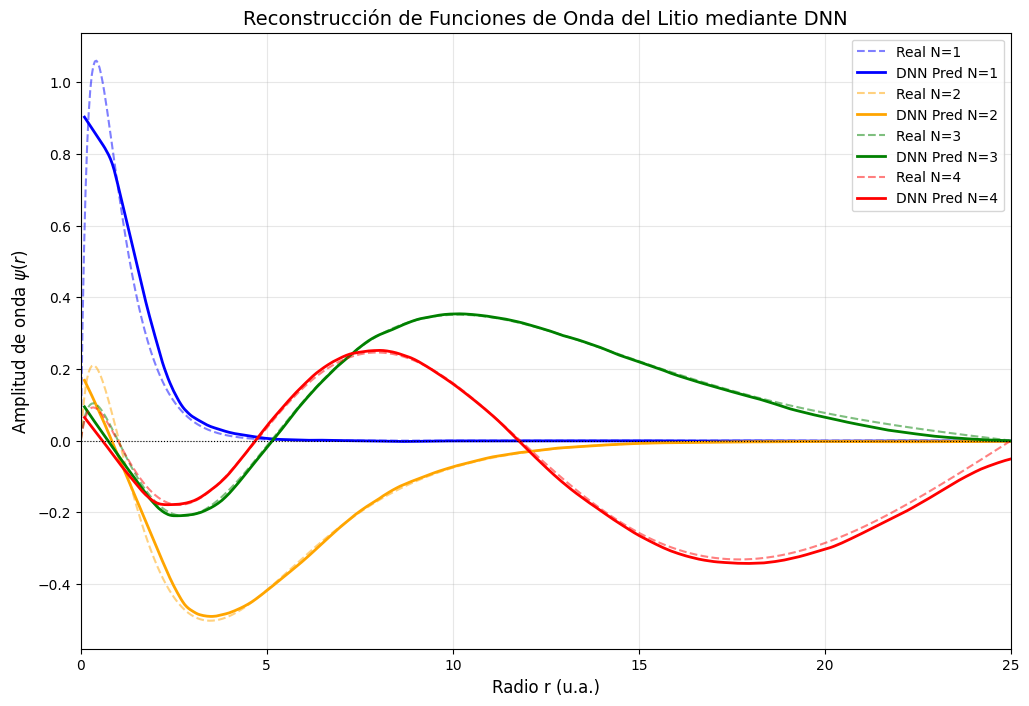

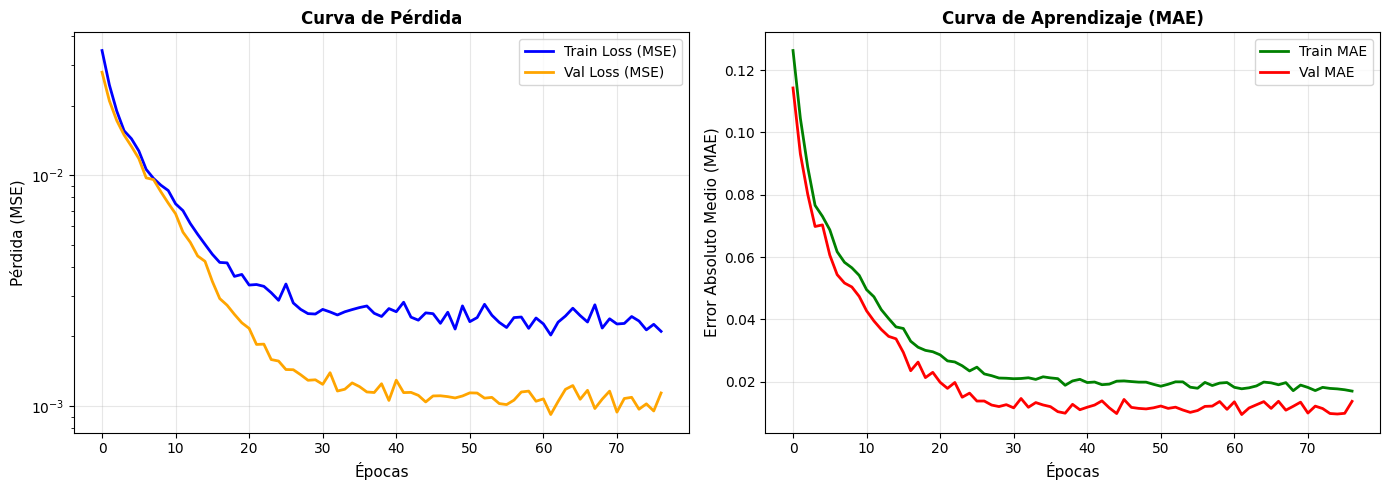

In [26]:
# ==========================================================
# 7. EVALUACIÓN Y RECONSTRUCCIÓN DE CURVAS
# ==========================================================
loss, mae = best_model.evaluate(X_test, y_test, verbose=0)
print(f"\nMAE en Test: {mae:.6f}")

# Vamos a pedirle a la red que reconstruya todas las curvas
plt.figure(figsize=(12, 8))
colores = ['blue', 'orange', 'green', 'red']

for n in range(1, estado_actual):
    # Crear un vector r sintético para graficar suavemente
    r_plot = np.linspace(0.1, 25.0, 500)
    n_plot = np.full_like(r_plot, n)

    # Escalar las entradas antes de predecir
    X_plot_scaled = scaler.transform(np.column_stack((r_plot, n_plot)))
    psi_pred = best_model.predict(X_plot_scaled, verbose=0)

    # Extraer los datos reales de este nivel para comparar
    r_real = [r_data[i] for i in range(len(r_data)) if n_data[i] == n]
    psi_real = [psi_data[i] for i in range(len(psi_data)) if n_data[i] == n]

    plt.plot(r_real, psi_real, color=colores[n-1], linestyle='--', alpha=0.5, label=f'Real N={n}')
    plt.plot(r_plot, psi_pred, color=colores[n-1], linewidth=2, label=f'DNN Pred N={n}')

plt.axhline(0, color='black', linewidth=0.8, linestyle=':')
plt.xlabel("Radio r (u.a.)", fontsize=12)
plt.ylabel("Amplitud de onda $\psi(r)$", fontsize=12)
plt.title("Reconstrucción de Funciones de Onda del Litio mediante DNN", fontsize=14)
plt.xlim(0, 25)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ==========================================================
# 8. CURVA DE ENTRENAMIENTO (LOSS + MAE)
# ==========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Loss (MSE)
axes[0].plot(history.history["loss"], label="Train Loss (MSE)", linewidth=2, color='blue')
axes[0].plot(history.history["val_loss"], label="Val Loss (MSE)", linewidth=2, color='orange')
axes[0].set_yscale('log')
axes[0].set_xlabel("Épocas", fontsize=11)
axes[0].set_ylabel("Pérdida (MSE)", fontsize=11)
axes[0].set_title("Curva de Pérdida", fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Gráfica 2: MAE (equivalente a "accuracy" para regresión)
axes[1].plot(history.history["mae"], label="Train MAE", linewidth=2, color='green')
axes[1].plot(history.history["val_mae"], label="Val MAE", linewidth=2, color='red')
axes[1].set_xlabel("Épocas", fontsize=11)
axes[1].set_ylabel("Error Absoluto Medio (MAE)", fontsize=11)
axes[1].set_title("Curva de Aprendizaje (MAE)", fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
import numpy as np

# ==========================================================
# 9. EXPORTAR PREDICCIONES A ARCHIVO .DAT
# ==========================================================
nombre_archivo_salida = "LITIO_PREDICCIONES_DNN.DAT"

print(f"Generando archivo {nombre_archivo_salida}...")
with open("LITIO_PYTHON0.DAT", "r") as f:
with open(nombre_archivo_salida, "w") as f:
    # Escribimos un encabezado descriptivo
    f.write("# Datos reconstruidos por la mejor Red Neuronal\n")
    f.write("# Columna 1: Radio r (u.a.) | Columna 2: Amplitud psi(r)\n\n")

    for n in range(1, estado_actual):
        # Creamos un barrido de r fino para una curva suave (1000 puntos por nivel)
        r_step = np.linspace(0.01, 25.0, 1000)
        n_step = np.full_like(r_step, n)

        # Preparar entrada para la red (stack + normalización)
        X_input = np.column_stack((r_step, n_step))
        X_input_scaled = scaler.transform(X_input)

        # Predicción
        psi_pred = best_model.predict(X_input_scaled, verbose=0).flatten()

        # Escribir los datos del nivel actual
        f.write(f"# ESTADO N = {n}\n")
        for i in range(len(r_step)):
            f.write(f"{r_step[i]:.10f}  {psi_pred[i]:.10f}\n")

        # Espacio en blanco entre bloques (estilo Fortran/Gnuplot)
        f.write("\n")

print(f"¡Listo! El archivo '{nombre_archivo_salida}' ha sido creado.")

IndentationError: expected an indented block after 'with' statement on line 9 (1130000377.py, line 10)